In [4]:
# load pandas untuk data wrangling
import pandas as pd
# load numpy untuk manipulasi vektor
import numpy as np
# load matplotlib untuk visualisasi data
import matplotlib.pyplot as plt
# load seaborn untuk visualisasi data
import seaborn as sns

# load metrics object dari sklearn
from sklearn import metrics
# load train-test data splitter
from sklearn.model_selection import train_test_split
# Import Decision Tree classifier (DT)
from sklearn.tree import DecisionTreeClassifier
# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
# load SVM classifier model
from sklearn.svm import SVC
# load KNN classifier model
from sklearn.neighbors import KNeighborsClassifier

#import for metrics
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline

In [5]:
import pandas as pd

dftrain = pd.read_csv('./data/customer_churn_dataset-training-master.csv')
dftest = pd.read_csv('./data/customer_churn_dataset-testing-master.csv')

In [6]:
dftrain.sample(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
166672,171483.0,49.0,Male,8.0,30.0,3.0,21.0,Standard,Annual,243.00,26.0,1.0
292071,299185.0,40.0,Female,32.0,6.0,2.0,17.0,Premium,Annual,645.93,11.0,0.0
45046,45626.0,61.0,Female,4.0,4.0,9.0,3.0,Standard,Monthly,230.00,14.0,1.0
132655,137025.0,44.0,Male,27.0,7.0,8.0,30.0,Basic,Monthly,868.00,1.0,1.0
322964,330079.0,40.0,Male,54.0,5.0,3.0,9.0,Basic,Quarterly,798.03,1.0,0.0
323897,331012.0,46.0,Male,7.0,12.0,4.0,18.0,Basic,Quarterly,560.78,2.0,0.0
10030,10039.0,31.0,Male,59.0,8.0,1.0,0.0,Premium,Annual,789.00,7.0,0.0
196838,201649.0,51.0,Male,2.0,10.0,8.0,17.0,Standard,Annual,318.00,3.0,1.0
145574,150385.0,48.0,Male,1.0,29.0,7.0,1.0,Standard,Annual,925.00,30.0,1.0
128396,132577.0,56.0,Male,9.0,23.0,2.0,7.0,Basic,Quarterly,239.00,13.0,1.0


In [7]:
dftest.sample(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
58311,58312,22,Male,48,28,5,16,Standard,Monthly,884,17,1
37193,37194,48,Female,5,6,10,15,Premium,Annual,382,8,0
18696,18697,60,Female,39,29,8,23,Premium,Quarterly,776,16,1
20282,20283,57,Female,59,19,10,22,Basic,Monthly,799,17,1
20612,20613,34,Male,14,22,8,3,Standard,Monthly,472,8,0
35225,35226,36,Male,6,14,6,8,Basic,Monthly,470,7,0
30672,30673,18,Female,32,30,2,13,Basic,Monthly,677,7,0
12985,12986,61,Male,56,21,9,14,Standard,Annual,242,27,0
16283,16284,33,Female,35,12,4,5,Basic,Monthly,595,24,0
12394,12395,51,Male,35,10,7,25,Premium,Monthly,850,9,1


## Preprocessing Data

### Handling Missing Value

In [8]:
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [9]:
dftrain.isna().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Karena hanya ada 1 data yang missing, jadi bisa dihapus saja

In [10]:
dftrain.dropna(inplace=True)

In [11]:
dftrain.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

### Handling Duplicated

In [12]:
dftrain.duplicated().sum()

0

Tidak terdapat data duplikat

### Handling Outlier

In [13]:
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB


In [14]:

# Menampilkan hanya nama kolom numerik
print(dftrain.select_dtypes(include=['int64', 'float64']).columns)

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


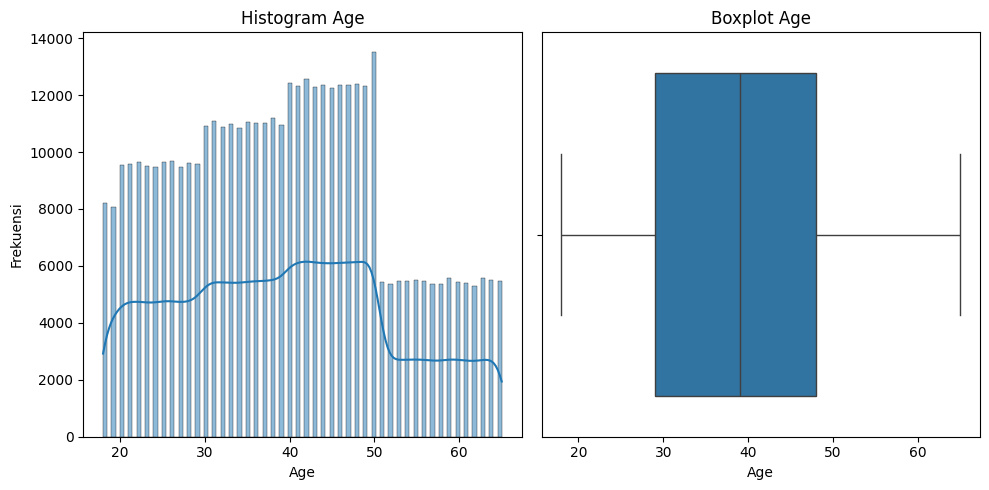

Statsitik Age:
count    440832.000000
mean         39.373153
std          12.442369
min          18.000000
25%          29.000000
50%          39.000000
75%          48.000000
max          65.000000
Name: Age, dtype: float64




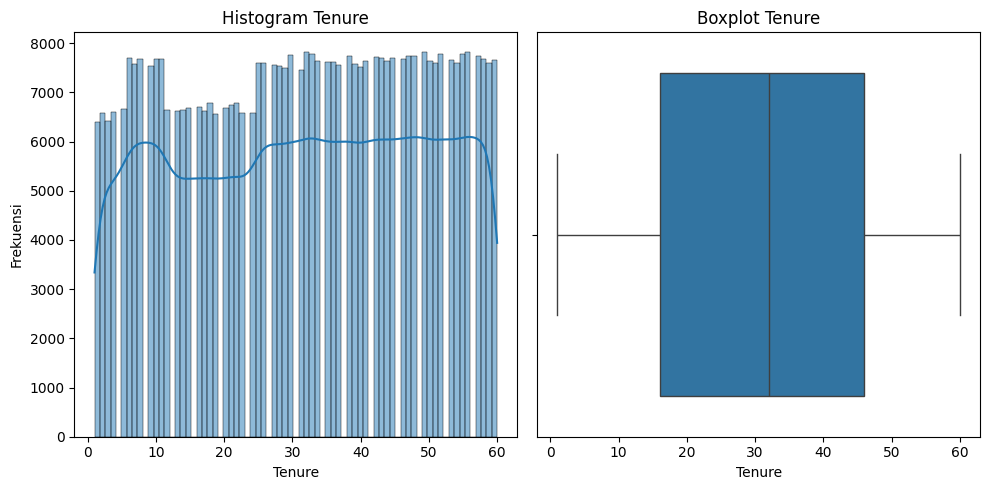

Statsitik Tenure:
count    440832.000000
mean         31.256336
std          17.255727
min           1.000000
25%          16.000000
50%          32.000000
75%          46.000000
max          60.000000
Name: Tenure, dtype: float64




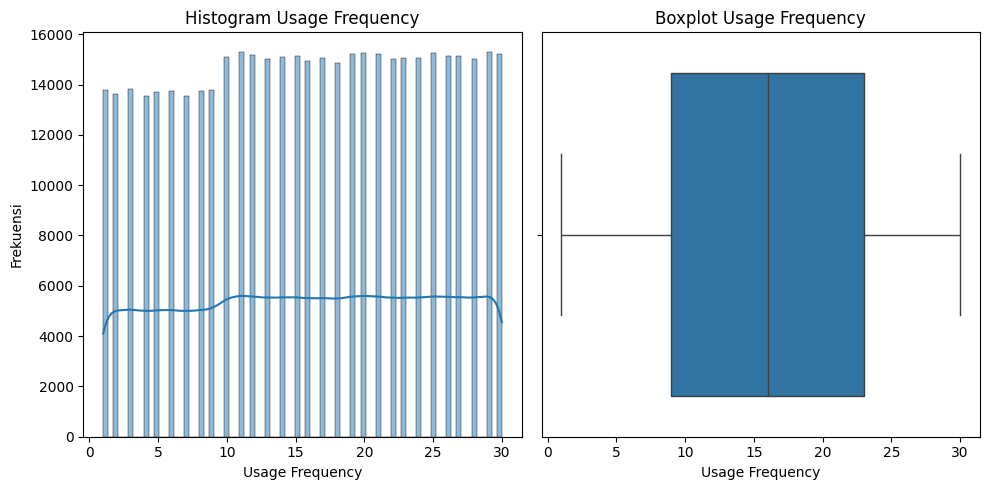

Statsitik Usage Frequency:
count    440832.000000
mean         15.807494
std           8.586242
min           1.000000
25%           9.000000
50%          16.000000
75%          23.000000
max          30.000000
Name: Usage Frequency, dtype: float64




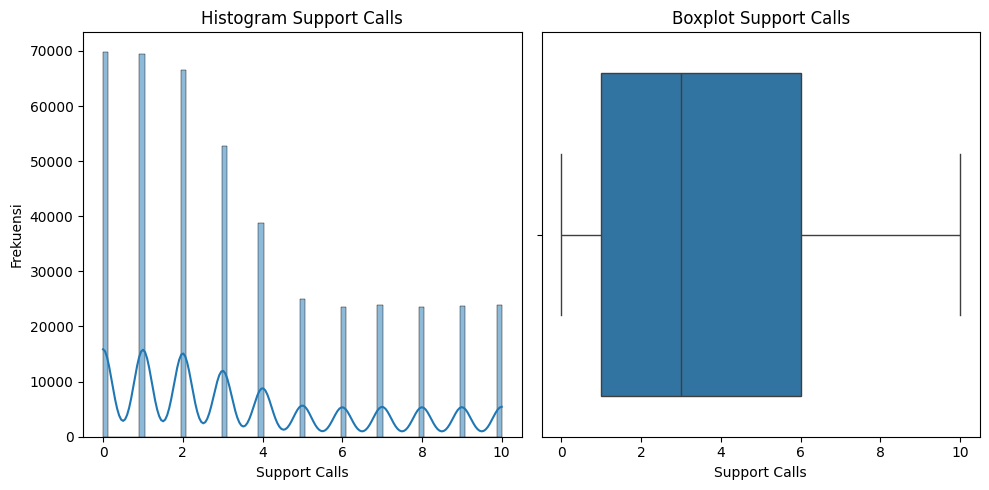

Statsitik Support Calls:
count    440832.000000
mean          3.604437
std           3.070218
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max          10.000000
Name: Support Calls, dtype: float64




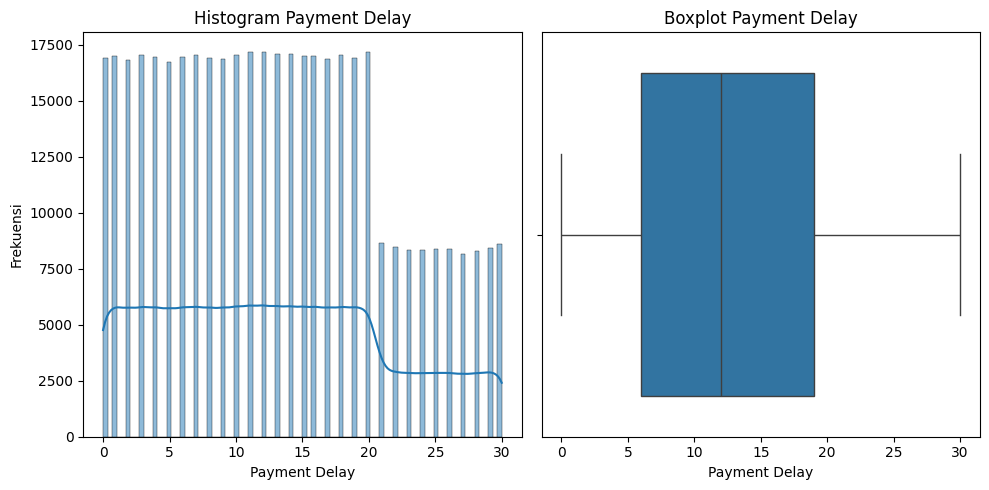

Statsitik Payment Delay:
count    440832.000000
mean         12.965722
std           8.258063
min           0.000000
25%           6.000000
50%          12.000000
75%          19.000000
max          30.000000
Name: Payment Delay, dtype: float64




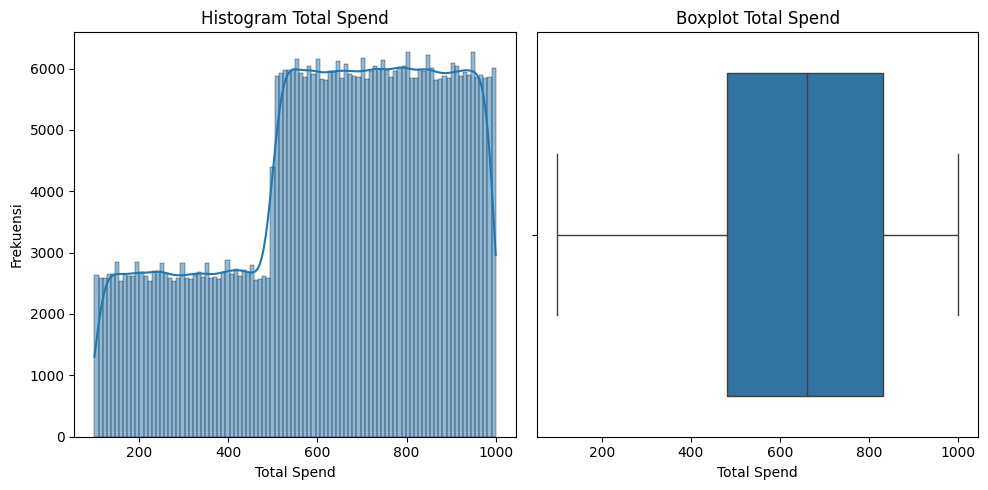

Statsitik Total Spend:
count    440832.000000
mean        631.616223
std         240.803001
min         100.000000
25%         480.000000
50%         661.000000
75%         830.000000
max        1000.000000
Name: Total Spend, dtype: float64




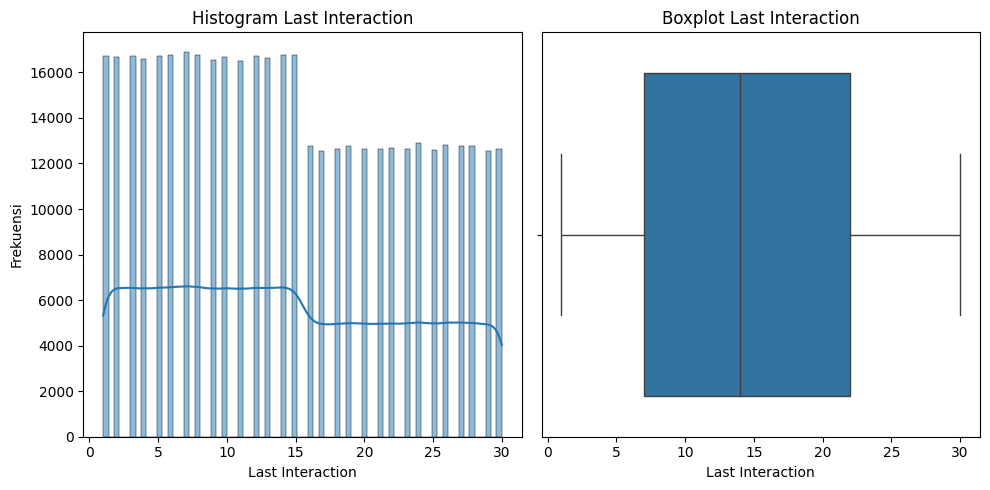

Statsitik Last Interaction:
count    440832.000000
mean         14.480868
std           8.596208
min           1.000000
25%           7.000000
50%          14.000000
75%          22.000000
max          30.000000
Name: Last Interaction, dtype: float64




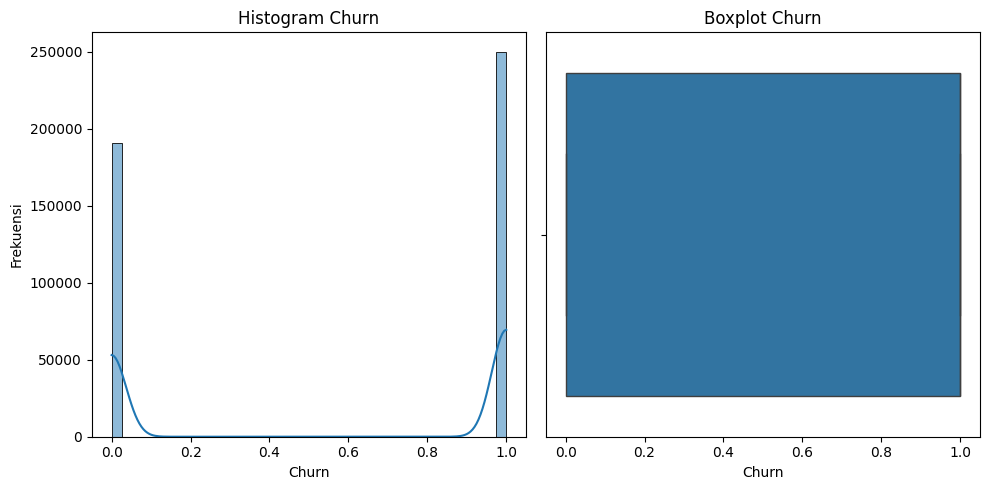

Statsitik Churn:
count    440832.000000
mean          0.567107
std           0.495477
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Churn, dtype: float64




In [15]:
kolomkolom = ('Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn')

for kolom in kolomkolom:
    fig, axes = plt.subplots(1,2,figsize=(10, 5))
    sns.histplot(x=dftrain[kolom], ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram {kolom}')
    axes[0].set_xlabel(kolom)
    axes[0].set_ylabel('Frekuensi')

    sns.boxplot(x=dftrain[kolom], ax=axes[1])
    axes[1].set_title(f'Boxplot {kolom}')
    axes[1].set_xlabel(kolom)

    plt.tight_layout()
    plt.show()

    # Menampilkan statistik data
    print(f'Statsitik {kolom}:')
    print(dftrain[kolom].describe())
    print('\n')


In [16]:
def handling_outlier_iqr(df, kolom):
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghapus outlier
    df_outlier_removed = df[(df[kolom] >= lower_bound) & (df[kolom] <= upper_bound)]

    return df_outlier_removed

kolomkolom = ('Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn')

for kolom in kolomkolom:
    print(f'Handling outlier pada kolom {kolom}:')
    dftrain_outlier_removed = handling_outlier_iqr(dftrain, kolom)
    print(f'Jumlah data sebelum handling outlier: {len(dftrain)}')
    print(f'Jumlah data setelah handling outlier: {len(dftrain_outlier_removed)}')
    print(f'Jumlah outlier yang dihapus: {len(dftrain) - len(dftrain_outlier_removed)}')
    print('\n')

    # Update dftrain
    dftrain = dftrain_outlier_removed



Handling outlier pada kolom Age:
Jumlah data sebelum handling outlier: 440832
Jumlah data setelah handling outlier: 440832
Jumlah outlier yang dihapus: 0


Handling outlier pada kolom Tenure:
Jumlah data sebelum handling outlier: 440832
Jumlah data setelah handling outlier: 440832
Jumlah outlier yang dihapus: 0


Handling outlier pada kolom Usage Frequency:
Jumlah data sebelum handling outlier: 440832
Jumlah data setelah handling outlier: 440832
Jumlah outlier yang dihapus: 0


Handling outlier pada kolom Support Calls:
Jumlah data sebelum handling outlier: 440832
Jumlah data setelah handling outlier: 440832
Jumlah outlier yang dihapus: 0


Handling outlier pada kolom Payment Delay:
Jumlah data sebelum handling outlier: 440832
Jumlah data setelah handling outlier: 440832
Jumlah outlier yang dihapus: 0


Handling outlier pada kolom Total Spend:
Jumlah data sebelum handling outlier: 440832
Jumlah data setelah handling outlier: 440832
Jumlah outlier yang dihapus: 0


Handling outlier pada

Telah dilakukan Handling Outlier

## Exploratory Data Analysis
- Lakukan analisa pada EDA menggunakan visualisasi di tiap variabel :
1. Kategorikal vs Churn Label
2. Numerik vs Churn Label
3. Anda wajib menuliskan insight, sebagai langkah untuk pencegahan churn dalam strategi marketing

In [17]:
dftrain.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [18]:
dftrain.describe(include='object')

,Gender,Subscription Type,Contract Length
count,440832,440832,440832
unique,2,3,3
top,Male,Standard,Annual
freq,250252,149128,177198


## Assignment Feature Engineering
1. Perhatikan splitting
2. Serta beri alasan anda dalam melakukan proses feature engineering di setiap prosesnya

### Label Encoding

In [19]:
kolomkolom = ['Gender', 'Subscription Type', 'Contract Length']

for kolom in kolomkolom:
    print(f'Unique value pada kolom {kolom}:')
    print(dftrain[kolom].unique())
    print(f'Jumlah unique value: {len(dftrain[kolom].unique())}')
    print('\n')

Unique value pada kolom Gender:
['Female' 'Male']
Jumlah unique value: 2


Unique value pada kolom Subscription Type:
['Standard' 'Basic' 'Premium']
Jumlah unique value: 3


Unique value pada kolom Contract Length:
['Annual' 'Monthly' 'Quarterly']
Jumlah unique value: 3




In [20]:
from sklearn.preprocessing import LabelEncoder

kolomkolom = ['Gender', 'Subscription Type', 'Contract Length']

le = LabelEncoder()

for kolom in kolomkolom:
    dftrain[kolom] = le.fit_transform(dftrain[kolom])
    print(f'Label Encoding pada kolom {kolom}:')
    print(le.classes_)
    print('\n')

Label Encoding pada kolom Gender:
['Female' 'Male']


Label Encoding pada kolom Subscription Type:
['Basic' 'Premium' 'Standard']


Label Encoding pada kolom Contract Length:
['Annual' 'Monthly' 'Quarterly']




In [21]:
from sklearn.preprocessing import LabelEncoder

kolomkolom = ['Gender', 'Subscription Type', 'Contract Length']

le = LabelEncoder()

for kolom in kolomkolom:
    dftrain[kolom] = le.fit_transform(dftrain[kolom])
    print(f'Label Encoding pada kolom {kolom}:')
    print(le.classes_)
    print('\n')

Label Encoding pada kolom Gender:
[0 1]


Label Encoding pada kolom Subscription Type:
[0 1 2]


Label Encoding pada kolom Contract Length:
[0 1 2]




### Splitting Data

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = dftrain.drop(['Churn'], axis=1)
y = dftrain['Churn']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (untuk Logistic Regression, KNN, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Assignment Modelling
1. Gunakan Machine Learning Model dibawah ini :
- Logistic Regression
- KNN
- Decision tree
- SVM RBF
- Dengan ratio : class_weight = balanced #class_weight = pembobotan, (kecuali pada KNN)
2. Lakukan fitting dan Model evaluasi di tiap model, keluarkan nilai pada confusion matrix (akurasi, recall, presisi, f1-score). Fokuslah pada nilai recall untuk menentukan model terbaik (melihat pada selisih nilai evaluasi di train dengan test). Pilihlah metrics (akurasi / recall / dsb) yg tepat serta berikan alasannya.

#### Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_logreg))
print(confusion_matrix(y_test, y_pred_logreg))


=== Logistic Regression ===
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97     38167
         1.0       0.98      0.97      0.98     50000

    accuracy                           0.98     88167
   macro avg       0.97      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167

[[37328   839]
 [ 1279 48721]]


#### KKN

In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN ===")
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


=== KNN ===
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     38167
         1.0       0.99      0.98      0.99     50000

    accuracy                           0.99     88167
   macro avg       0.99      0.99      0.99     88167
weighted avg       0.99      0.99      0.99     88167

[[37890   277]
 [  805 49195]]


#### Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))


=== Decision Tree ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167

[[38147    20]
 [   10 49990]]


#### SVM

In [26]:
from sklearn.svm import SVC

svm_rbf = SVC(kernel='rbf', class_weight='balanced')
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm = svm_rbf.predict(X_test_scaled)

print("=== SVM RBF ===")
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))


#### Perbandingan semua model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Dictionary model dan prediksi
model_predictions = {
    "Logistic Regression": y_pred_logreg,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "SVM RBF": y_pred_svm
}

# Tabel hasil evaluasi
evaluation_results = []

for model_name, y_pred in model_predictions.items():
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    }
    evaluation_results.append(results)

df_eval = pd.DataFrame(evaluation_results)
df_eval


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.975977,0.983071,0.97442,0.978726,0.976219
1,KNN,0.987728,0.994401,0.98390,0.989123,0.988321
2,Decision Tree,0.999660,0.999600,0.99980,0.999700,0.999638
3,SVM RBF,0.994023,0.993871,0.99560,0.994735,0.993778


Hasil evaluasi menunjukkan bahwa seluruh model klasifikasi memiliki performa yang sangat tinggi, namun masing-masing menunjukkan karakteristik yang berbeda dalam menyeimbangkan akurasi, kemampuan mendeteksi churn (recall), dan ketepatan prediksi (precision). **Decision Tree** tampil sebagai model dengan performa terbaik secara keseluruhan, ditunjukkan oleh nilai akurasi, precision, recall, F1-score, serta ROC-AUC yang hampir sempurna (mendekati 1.0). Hal ini mengindikasikan bahwa model mampu menangkap pola pada data training dan validation dengan sangat efektif, meskipun perlu diwaspadai potensi overfitting mengingat performanya yang terlalu tinggi. **SVM RBF** berada pada posisi berikutnya dengan performa yang sangat stabil dan konsisten di seluruh metrik, terutama recall yang tinggi, sehingga model ini sangat baik dalam mengidentifikasi pelanggan churn. **KNN** juga memberikan hasil yang sangat kompetitif, meskipun performanya sedikit di bawah SVM RBF. Model ini memiliki keseimbangan metrik yang baik dan ROC-AUC yang sangat tinggi, menunjukkan kemampuan memisahkan kelas churn dan non-churn dengan akurasi yang kuat. **Logistic Regression**, meskipun menjadi model paling sederhana, tetap menunjukkan performa yang sangat baik dengan nilai evaluasi di atas 0.97 pada hampir seluruh metrik, mencerminkan bahwa pola churn dalam dataset cukup linear dan mudah ditangkap oleh model berbasis regresi. Secara keseluruhan, hasil ini mengindikasikan bahwa dataset memiliki struktur yang jelas dan dapat diprediksi dengan baik oleh berbagai algoritma, meskipun model seperti Decision Tree yang terlalu sempurna perlu dianalisis lebih lanjut untuk memastikan generalisasi yang optimal.


### Assignment Profitable :
1. Lakukan perhitungan profitable dengan asumsi biaya yang anda buat sendiri.

In [ ]:
dftrain.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

Biaya ini merupakan asumsi:

1. fixed_cost = 8   # biaya tetap per pelanggan
2. usage_cost = 0.20   # biaya per unit penggunaan
3. support_call_cost = 1.50 # biaya per panggilan support
4. delay_cost = 0.50    # biaya per payment delay


In [ ]:
# ASUMSI BIAYA
fixed_cost = 8
usage_cost = 0.20
support_call_cost = 1.50
delay_cost = 0.50

# HITUNG BIAYA VARIABEL
dftrain['Variable_Cost'] = (
    dftrain['Usage Frequency'] * usage_cost +
    dftrain['Support Calls'] * support_call_cost +
    dftrain['Payment Delay'] * delay_cost
)

# HITUNG TOTAL COST
dftrain['Total_Cost'] = dftrain['Variable_Cost'] + fixed_cost

# HITUNG PROFIT
dftrain['Profit'] = dftrain['Total Spend'] - dftrain['Total_Cost']

# Tampilkan 5 baris pertama
dftrain.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Variable_Cost,Total_Cost,Profit
0,2.0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1.0,19.3,27.3,904.7
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1.0,19.2,27.2,529.8
2,4.0,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1.0,18.8,26.8,158.2
3,5.0,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1.0,18.2,26.2,369.8
4,6.0,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1.0,15.5,23.5,593.5


In [ ]:
total_profit = dftrain['Profit'].sum()
total_revenue = dftrain['Total Spend'].sum()
total_cost = dftrain['Total_Cost'].sum()

total_profit, total_revenue, total_cost


(np.float64(268275017.91999996),
 np.float64(278436642.7200001),
 np.float64(10161624.799999999))

In [ ]:
profit_by_churn = dftrain.groupby('Churn')['Profit'].mean()
profit_by_churn

,Profit
Churn,
0.0,731.313623
1.0,514.867041


#### Visualisasi

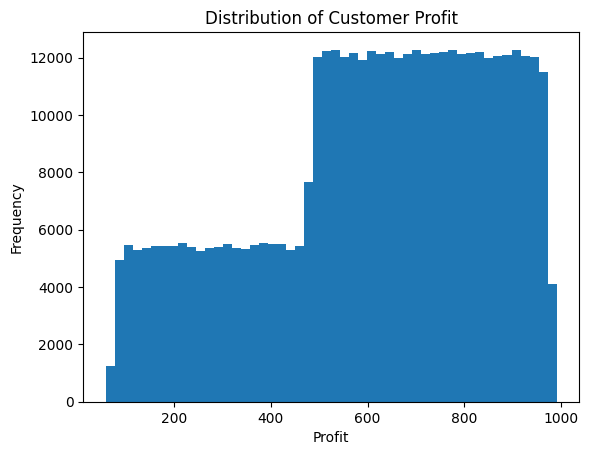

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(dftrain['Profit'], bins=50)
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Profit')
plt.show()


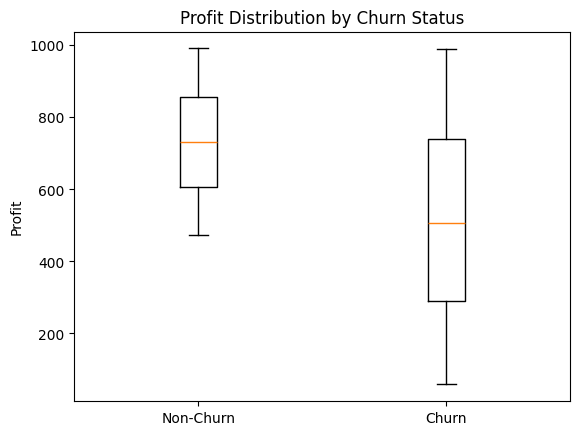

In [ ]:
plt.figure()
plt.boxplot([
    dftrain[dftrain['Churn'] == 0]['Profit'],
    dftrain[dftrain['Churn'] == 1]['Profit']
])
plt.xticks([1, 2], ['Non-Churn', 'Churn'])
plt.ylabel('Profit')
plt.title('Profit Distribution by Churn Status')
plt.show()


## Notes :
Kumpulkan di LMS link google collab yang sudah dibuka aksesnya + sudah di run dan save output codenya. Serta jangan di private